We have been doing feature transformation up until now . This tutorial covers function transformer :
A. mathematical transformers
1. log trans
2. reciprocal
3. square/sq root

There are other transformers(power transformers) like :
1. box -cox
2. yeo-johnson




We need these transformers to transform our data so that they have a normal distribution rather than skewed or something else. Such normal distribution increases the accuracy of the model like linear regression , logistic regression etc. Some models dont care about normal distribution like decision tree , random forest etc.

Sklearn has 3 types of transformers:

1. Function Transformer
2. Power transformer
3. Quantile transformer

**How to find if data is normal or not ?**

1. use sns.distplot()
2. pd.skew() if is 0.
3. QQ plot

_Log transform is mainly used when the data is right skewed .
square(x^2) is mainly used when the data is left skewd.
Although check all the transformers to see which one works better for which._

In [42]:
#code

In [43]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [44]:
df = pd.read_csv('titanic_train.csv' , usecols = ['Age' ,'Fare', 'Survived'])


In [45]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [46]:
df.isnull().sum()
#age has 177 missing values .


Survived      0
Age         177
Fare          0
dtype: int64

In [47]:
#replacing the missing age values with its mean
df['Age'].fillna(df['Age'].mean() , inplace = True)

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_7618/2374780409.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean() , inplace = True)


In [48]:
df.sample(10)


,Survived,Age,Fare
613,0,29.699118,7.7500
533,1,29.699118,22.3583
572,1,36.000000,26.3875
747,1,30.000000,13.0000
123,1,32.500000,13.0000
189,0,36.000000,7.8958
214,0,29.699118,7.7500
506,1,33.000000,26.0000
207,1,26.000000,18.7875
173,0,21.000000,7.9250


In [49]:
x = df.iloc[:,1:]
y = df.iloc[:, 0]

In [50]:
#TRAIN TEST SPLIT
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42) #(data to use:df.drop, target col,)


/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_7618/3287212292.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


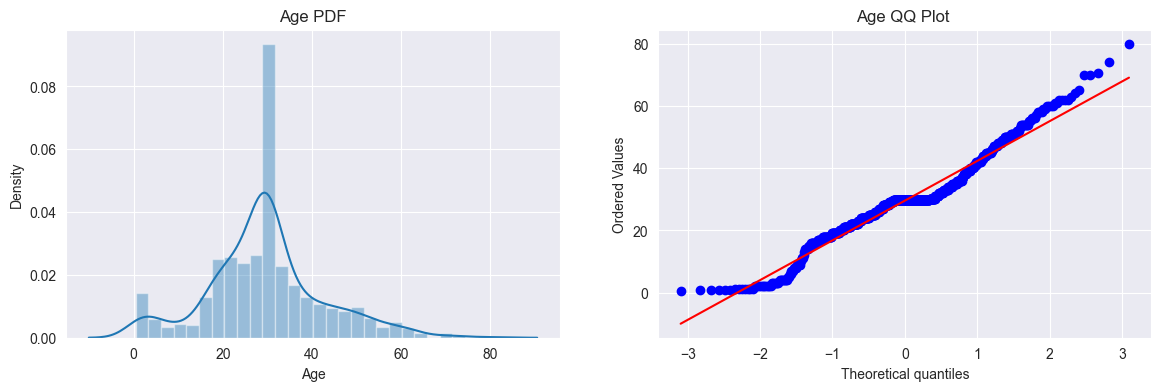

In [51]:
#checking if age and fare are normally distributed or not .

plt.figure(figsize = (14, 4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'] , dist = "norm" , plot = plt)
plt.title('Age QQ Plot ')

plt.show()

#slightly bad at the left side

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_7618/379001349.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


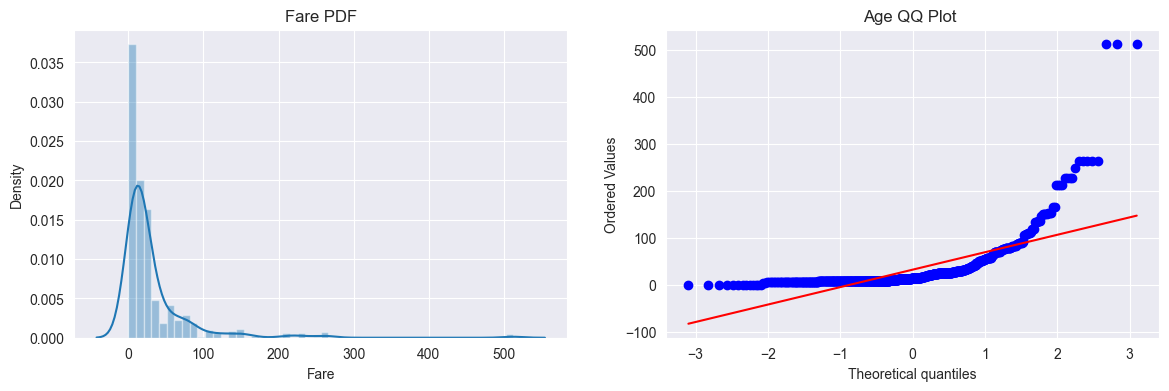

In [52]:
plt.figure(figsize = (14, 4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'] , dist = "norm" , plot = plt )
plt.title('Age QQ Plot ')

plt.show()


#it can be seen data is right skewed .

In [53]:
#working on the data without fixing them
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [54]:
clf.fit(x_train, y_train)
clf2.fit(x_train , y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("Accuracy LR" , accuracy_score(y_test , y_pred))
print("Accuracy DT" , accuracy_score(y_test , y_pred))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6480446927374302


In [55]:
#Applying function transformers
trf = FunctionTransformer(func = np.log1p) #log1p means log(1+x) so that fnc is defined for x = 0 too.

In [56]:
#function transformer applied
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [57]:
#training the models

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed , y_train)
clf2.fit(x_train_transformed , y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("Accuracy LR" ,accuracy_score(y_test , y_pred))
print("Accuracy DT" , accuracy_score(y_test, y_pred2))


#can be observed that decision tree algos accuracy has decreased after using the function transformer . hence we will un_apply it on the data and check the accuracy.

Accuracy LR 0.7374301675977654
Accuracy DT 0.5865921787709497


In [58]:
#cross validation confirms accuracy.

x_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Accuracy LR" ,np.mean(cross_val_score(clf , x_transformed , y,scoring = 'accuracy' , cv = 10)))


print("Accuracy DT" ,np.mean(cross_val_score(clf2 , x_transformed , y,scoring = 'accuracy' , cv = 10)))







Accuracy LR 0.678027465667915
Accuracy DT 0.6521348314606742


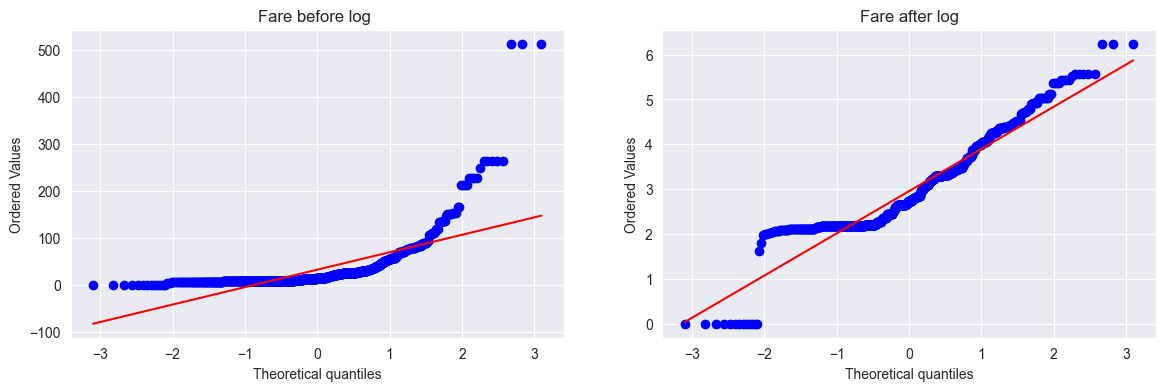

In [61]:
plt.figure(figsize = (14, 4))


plt.subplot(121)
stats.probplot(x_train['Fare'] , dist = "norm" , plot = plt )
plt.title('Fare before log ')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'] ,dist = "norm" , plot = plt)
plt.title('Fare after log')

plt.show()

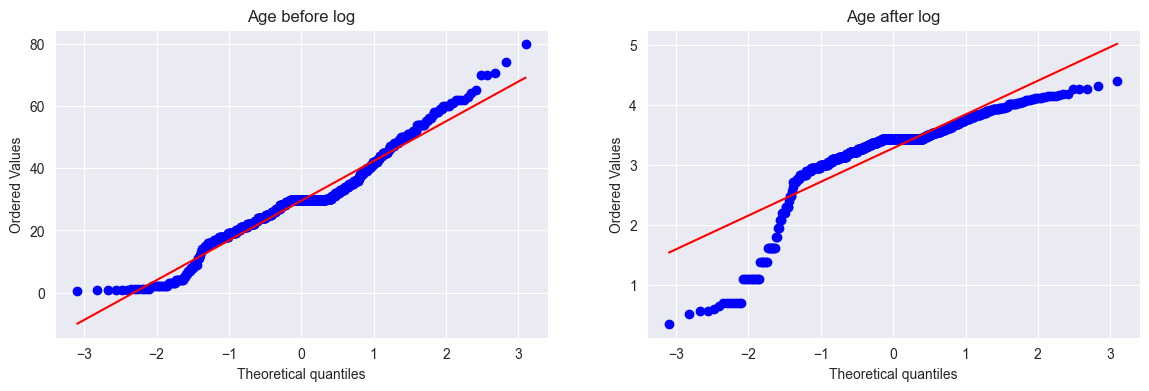

In [60]:
plt.figure(figsize = (14, 4))

plt.subplot(121)
stats.probplot(x_train['Age'] , dist = "norm" ,plot = plt)
plt.title('Age before log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'] , dist = "norm" , plot = plt)
plt.title('Age after log')

plt.show()


In [63]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder = 'passthrough')

x_train_transformed2 = trf2.fit_transform(x_train)
x_test_transformed2 = trf2.transform(x_test)

In [66]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed2 , y_train)
clf2.fit(x_train_transformed2 , y_train)

y_pred = clf.predict(x_test_transformed2)
y_pred2 = clf2.predict(x_test_transformed2 )

print("Accuracy LR", accuracy_score(y_test , y_pred))
print("Accuracy DT" , accuracy_score(y_test, y_pred))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6703910614525139


Square /square root transformations

In [67]:
def apply_transform(transform) :
    x = df.iloc[:,1:3]
    y = df.iloc[:, 0]

    trf = ColumnTransformer([('log', FunctionTransformer(transform),['Fare'])], remainder = 'passthrough')

    x_trans = trf.fit_transform(x)

    clf = LogisticRegression()

    print("Accuracy" , np.mean(cross_val_score(clf, x_trans ,y, scoring  = 'accuracy' , cv = 10)))

    plt.figure(figsize =(14, 4))


    plt.subplot(121)
    stats.probplot(x['Fare'] , dist = "norm" , plot= plt)
    plt.title('Fare before transform')


    plt.subplot(122)
    stats.probplot(x_trans[: ,0] , dist = "norm" , plot = plt)
    plt.title('Fare after transform ')

    plt.show()

Accuracy 0.6431335830212235


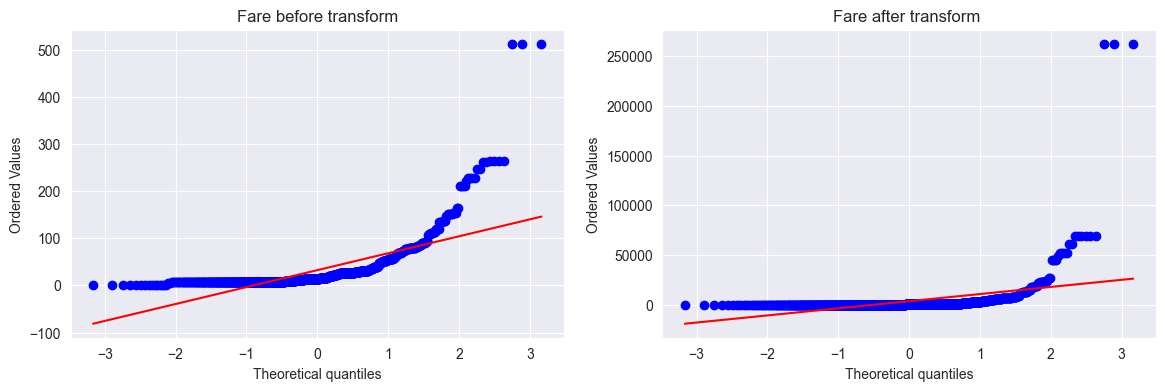

In [68]:
apply_transform(lambda x: x**2)


Accuracy 0.6262796504369538


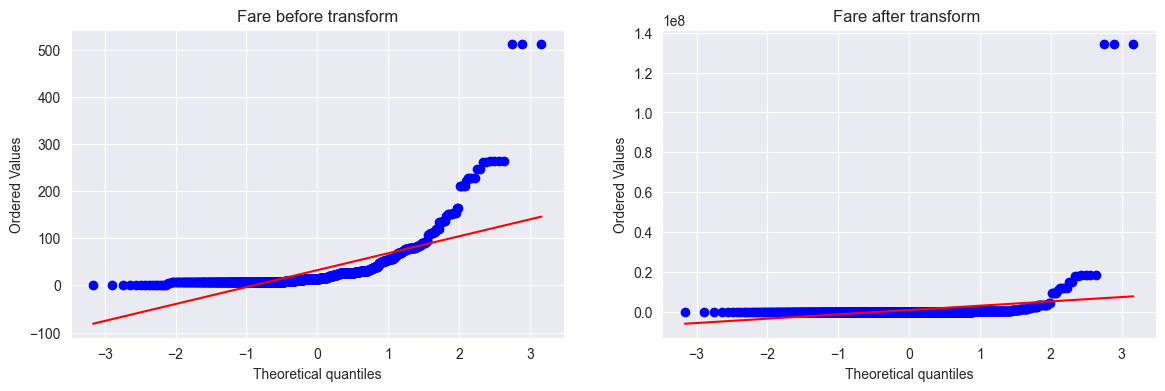

In [69]:
apply_transform(lambda x: x**3)


Accuracy 0.6589013732833957


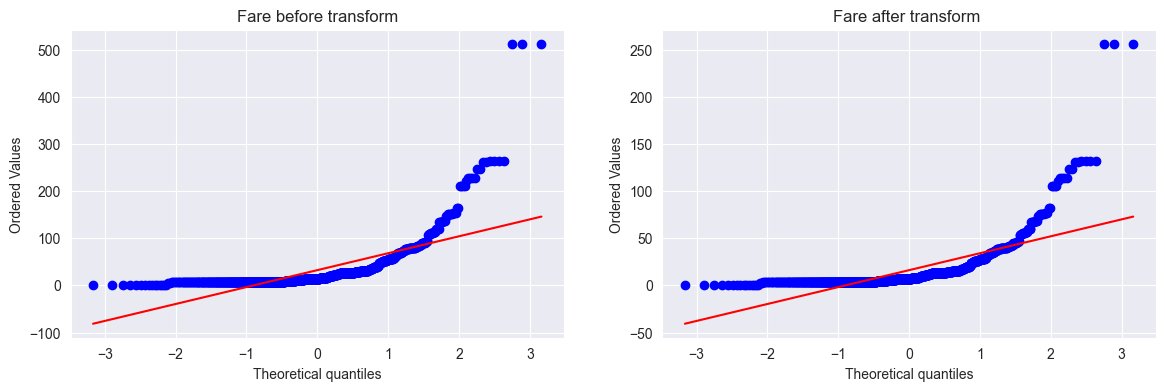

In [70]:
apply_transform(lambda x: x**1/2)


In [89]:
apply_transform(lambda x: 1/x+0.1)


ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py", line 1459, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
    